In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [16]:
df = pd.read_csv("cardio_preprocessed.csv", sep=",")
df

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi
0,0.600000,2,0.579487,0.273684,0.016079,0.013550,0.0,0.0,0.0,0.0,1.0,0.0,21.967120
1,0.742857,1,0.517949,0.394737,0.017934,0.014453,1.0,0.0,0.0,0.0,1.0,1.0,34.927679
2,0.628571,1,0.564103,0.284211,0.017316,0.012647,1.0,0.0,0.0,0.0,0.0,1.0,23.507805
3,0.542857,2,0.584615,0.378947,0.018553,0.015357,0.0,0.0,0.0,0.0,1.0,1.0,28.710479
4,0.885714,1,0.492308,0.300000,0.016698,0.013550,0.5,0.5,0.0,0.0,0.0,0.0,29.384676
...,...,...,...,...,...,...,...,...,...,...,...,...,...
62473,0.685714,1,0.600000,0.315789,0.017316,0.014453,0.0,0.0,0.0,0.0,1.0,1.0,23.661439
62474,0.800000,1,0.564103,0.368421,0.018553,0.013550,0.0,0.0,0.0,0.0,1.0,1.0,29.384757
62475,0.657143,2,0.579487,0.347368,0.016698,0.013550,0.0,0.0,1.0,0.0,1.0,0.0,26.927438
62476,0.914286,1,0.553846,0.326316,0.017625,0.013550,0.0,0.5,0.0,0.0,0.0,1.0,27.099251


In [17]:
print(df.columns)

Index(['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol',
       'gluc', 'smoke', 'alco', 'active', 'cardio', 'bmi'],
      dtype='object')


In [25]:
X = df.drop('cardio',axis=1)
Y = df['cardio']

### Train and test the model

In [26]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
#this is for splitting data into train and test 80% train and 20% test and also for avoid overfitting we use random_state=42
#state=42 means that the random number generator will produce the same sequence of numbers each time you run the code.

### Scale the data

In [27]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
#standarScalar is used to standardize featureas by removing the mean and scaling to unit variance.

### Logistic regression

In [28]:
log_model = LogisticRegression()
log_model.fit(X_train,Y_train)
# logistic regression is used for binary classification problem

LogisticRegression()

### Predict logistic Model

In [29]:
Y_pred_log = log_model.predict(X_test)

### Evaluate Logistic Model

In [30]:
print("Accuracy:", accuracy_score(Y_test, Y_pred_log))
print(confusion_matrix(Y_test, Y_pred_log))
print(classification_report(Y_test, Y_pred_log))
#confusion matrix is used to evaluate the performance of a classification algorithm
#classification report is used to evaluate the precision, recall, f1-score of the model
#precision is the ratio of correctly predicted positive observations to the total predicted positives.
#recall is the ratio of correctly predicted positive observations to all actual positives.
#f1-score is the weighted average of precision and recall.

Accuracy: 0.729673495518566
[[5108 1324]
 [2054 4010]]
              precision    recall  f1-score   support

         0.0       0.71      0.79      0.75      6432
         1.0       0.75      0.66      0.70      6064

    accuracy                           0.73     12496
   macro avg       0.73      0.73      0.73     12496
weighted avg       0.73      0.73      0.73     12496



In [31]:
train_pred = log_model.predict(X_train)
test_pred = log_model.predict(X_test)

train_acc = accuracy_score(Y_train, train_pred)
test_acc = accuracy_score(Y_test, test_pred)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 0.7224600856308271
Testing Accuracy: 0.729673495518566


In [33]:
#hyperparameter tuning using GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

grid = GridSearchCV(LogisticRegression(max_iter=200), param_grid, cv=5)
grid.fit(X_train, Y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)
# C → Controls how strict the model is. Smaller C = stronger regularization.
#     We test 0.01, 0.1, 1, and 10 to see which gives best accuracy.
# penalty → Type of regularization. We use L2 because it is stable and works well.
# solver → The algorithm used to train logistic regression.
#     'lbfgs' → fast and stable, good for small to medium data.
#     'liblinear' → best for binary classification problems.

Best Parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
Best Score: 0.7219999333133273


### Random Forest

In [34]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42);
rf.fit(X_train, Y_train)

#n_estimators is the number of trees in the forest
#max_depth is the maximum depth of the tree
#random_state is used for reproducibility

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

### Predict using random forest

In [35]:
Y_pred_rf = rf.predict(X_test)

In [36]:
print("RF Accuracy:", accuracy_score(Y_test, Y_pred_rf))
print(confusion_matrix(Y_test, Y_pred_rf))
print(classification_report(Y_test, Y_pred_rf))

RF Accuracy: 0.7368758002560819
[[5127 1305]
 [1983 4081]]
              precision    recall  f1-score   support

         0.0       0.72      0.80      0.76      6432
         1.0       0.76      0.67      0.71      6064

    accuracy                           0.74     12496
   macro avg       0.74      0.74      0.74     12496
weighted avg       0.74      0.74      0.74     12496



## Visualization

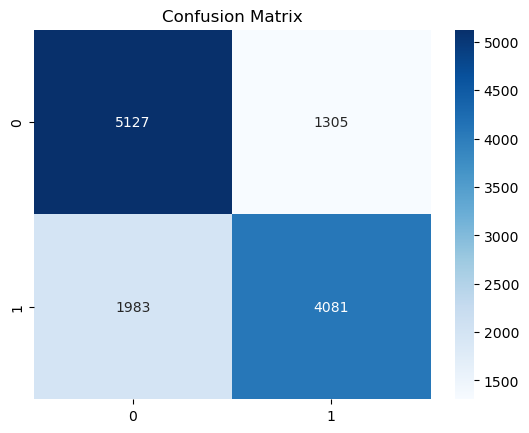

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(Y_test, Y_pred_rf)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()

## ROC curve

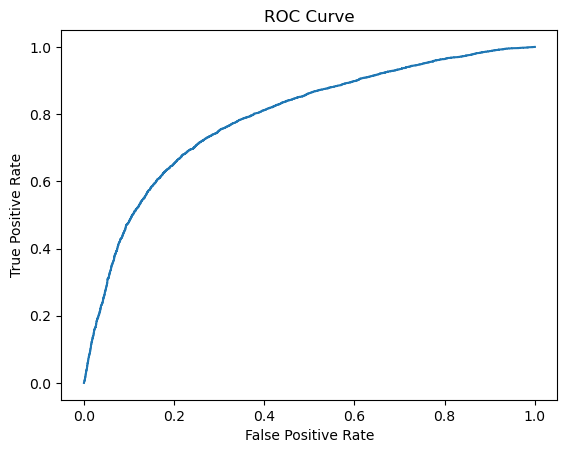

In [39]:
from sklearn.metrics import roc_curve, auc

Y_prob = log_model.predict_proba(X_test)[:,1]
fpr, tpr, threshold = roc_curve(Y_test, Y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [40]:
import pickle
import os
#pickle is used for serializing and deserializing a Python object structure.

# Create model folder if not exists
if not os.path.exists("model"):
    os.makedirs("model")

# Save Random Forest model
pickle.dump(rf, open("model/model.pkl", "wb"))

# Save scaler used during training
pickle.dump(scaler, open("model/scaler.pkl", "wb"))

print("Random Forest model and scaler saved successfully!")

Random Forest model and scaler saved successfully!


In [45]:
print("Scaler expects:", scaler.n_features_in_)

Scaler expects: 12


### K-Fold Cross Validation

In [44]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

kfold = KFold(
    n_splits=5,      # 5-fold CV
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    model,
    X,
    Y,
    cv=kfold,
    scoring='accuracy'
)

print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Cross-validation scores: [0.63900448 0.63940461 0.64612676 0.64305722 0.63161265]
Mean CV Accuracy: 0.63984114388393
